<a href="https://colab.research.google.com/github/Crounous/EfficientNet-B0/blob/main/EfficientNet_B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Preprocessing Stage**

**Step 1:** Import Dataset (M.Herrot)





**Step 2.0:** Combine csv files (Test, Train, Validation) into one **(Already Done, Do not Run)**



In [ ]:
import pandas as pd
import os

base_path = 'G:\My Drive\DRdataset'

train_path = os.path.join(base_path, 'train_1.csv')
test_path = os.path.join(base_path, 'test.csv')
validation_path = os.path.join(base_path, 'valid.csv')

if not all(os.path.exists(p) for p in [train_path, test_path, validation_path]):
    print("Error: One or more CSV files not found.")
    print(f"Expected paths:")
    print(f"  Train: {train_path}")
    print(f"  Test: {test_path}")
    print(f"  Validation: {validation_path}")

    if os.path.exists(base_path):
        print(f"Files in {base_path}: {os.listdir(base_path)}")
    else:
        print(f"Base path {base_path} does not exist. Did you mount Drive correctly?")

else:
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    df_val = pd.read_csv(validation_path)

    df_train['split'] = 'train'
    df_test['split'] = 'test'
    df_val['split'] = 'validation'

    combined_df = pd.concat([df_train, df_test, df_val], ignore_index=True)

    output_filename = os.path.join(base_path, 'dataset.csv')
    combined_df.to_csv(output_filename, index=False)

    print(f"Successfully combined CSVs into '{output_filename}' in your Google Drive.")
    print(f"Combined DataFrame shape: {combined_df.shape}")
    print(f"First 5 rows of combined data:\n{combined_df.head()}")
    print(f"Value counts of the 'split' column (if added):\n{combined_df['split'].value_counts()}")

**Step 2.1:** creating the 5-fold splits **(Already Done, Do not Run)**

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from shutil import copyfile, rmtree

base_data_path = 'G:\My Drive\DRdataset'

images_folder_name = 'images'
labels_csv_name = 'dataset.csv'

images_path = os.path.join(base_data_path, images_folder_name)
labels_csv_path = os.path.join(base_data_path, labels_csv_name)

## For defining the paths of the 5-folds

print(f"Base data path: {base_data_path}")
print(f"Images folder path: {images_path}")
print(f"Labels CSV path: {labels_csv_path}")

if not os.path.exists(images_path):
    print(f"Error: Images folder not found at {images_path}")
    print("Please check your `base_data_path` and `images_folder_name`.")
if not os.path.exists(labels_csv_path):
    print(f"Error: Labels CSV not found at {labels_csv_path}")
    print("Please check your `base_data_path` and `labels_csv_name`.")

output_splits_folder = os.path.join(base_data_path, 'DataSplits')
os.makedirs(output_splits_folder, exist_ok=True)
print(f"Output splits will be saved in: {output_splits_folder}")

## For removing the existing 'split' column and appending .png to label column

try:
    df_labels = pd.read_csv(labels_csv_path)
    print(f"Original labels DataFrame shape: {df_labels.shape}")

    if 'split' in df_labels.columns:
        df_labels = df_labels.drop(columns=['split'])
        print("Successfully removed 'split' column.")
    else:
        print("'split' column not found in the DataFrame. No action needed.")

    df_labels = df_labels.rename(columns={'id_code': 'image_filename', 'diagnosis': 'label'})
    df_labels['image_filename'] = df_labels['image_filename'].astype(str) + '.png'
    print("Appended '.png' extension to 'image_filename' column.")

    print(f"Updated labels DataFrame shape: {df_labels.shape}")
    print("Updated label distribution:")
    print(df_labels['label'].value_counts())

except Exception as e:
    print(f"Failed to load or process labels CSV: {e}")
    exit()

## For creating the 5 splits

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
X = df_labels['image_filename']
y = df_labels['label']

print(f"\nStarting {k}-fold cross-validation...")

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"\n--- Processing Fold {fold + 1}/{k} ---")

    fold_dir = os.path.join(output_splits_folder, f'fold_{fold + 1}')
    train_images_dir = os.path.join(fold_dir, 'train_images')
    test_images_dir = os.path.join(fold_dir, 'test_images')

    if os.path.exists(fold_dir):
        rmtree(fold_dir)
    os.makedirs(train_images_dir, exist_ok=True)
    os.makedirs(test_images_dir, exist_ok=True)

    df_train_fold = df_labels.iloc[train_index].copy()
    df_test_fold = df_labels.iloc[test_index].copy()

    train_csv_path = os.path.join(fold_dir, 'train_labels.csv')
    test_csv_path = os.path.join(fold_dir, 'test_labels.csv')
    df_train_fold.to_csv(train_csv_path, index=False)
    df_test_fold.to_csv(test_csv_path, index=False)
    print(f"  Fold {fold + 1} train labels saved to: {train_csv_path}")
    print(f"  Fold {fold + 1} test labels saved to: {test_csv_path}")

    X_train_filenames = df_train_fold['image_filename']
    X_test_filenames = df_test_fold['image_filename']

    print(f"  Train set size: {len(X_train_filenames)} | Test set size: {len(X_test_filenames)}")
    print("  Train set label distribution:")
    print(df_train_fold['label'].value_counts(normalize=True))
    print("  Test set label distribution:")
    print(df_test_fold['label'].value_counts(normalize=True))

    for img_filename in X_train_filenames:
        src_path = os.path.join(images_path, img_filename)
        dst_path = os.path.join(train_images_dir, img_filename)
        if os.path.exists(src_path):
            copyfile(src_path, dst_path)
        else:
            print(f"    Warning: Image not found (Train): {src_path}")

    for img_filename in X_test_filenames:
        src_path = os.path.join(images_path, img_filename)
        dst_path = os.path.join(test_images_dir, img_filename)
        if os.path.exists(src_path):
            copyfile(src_path, dst_path)
        else:
            print(f"    Warning: Image not found (Test): {src_path}")
    print(f"  Finished copying images for Fold {fold + 1}.")

print("\nK-fold splitting complete!")
print(f"All splits (CSV files and image folders) are saved under: {output_splits_folder}")

**Step 2.2:** dimension manipulation and augmentation **(FINISHED. DO NOT RUN!!)**

In [ ]:
import cv2
import numpy as np
import os
import pandas as pd
from PIL import Image
import imgaug.augmenters as iaa
import imgaug as ia

base_data_path = '/content/drive/MyDrive/DRdataset/'
output_splits_folder = os.path.join(base_data_path, 'DataSplits')


img_width, img_height = 224, 224

# Augmentation parameters
rotate_range = (-20, 20)
gaussian_blur_sigma_range = (0.5, 2.0)
noise_ranges = [25, 40, 50]


augmenter_rotate = iaa.Sequential([
    iaa.Sometimes(0.7, iaa.Rotate(rotate_range))
])

augmenter_blur = iaa.Sequential([
    iaa.Sometimes(0.5, iaa.GaussianBlur(sigma=gaussian_blur_sigma_range))
])

augmenter_noise = iaa.Sequential([
    iaa.AdditiveGaussianNoise(scale=(0.0 * 255, 0.15 * 255), per_channel=0.5)
])

max_class_count = 5000

#Remove background + Resize

def preprocess_image(image_path, output_size):
    try:
        img = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if img is None:
            print(f"Warning: Could not read image {image_path}")
            return None

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            print(f"Warning: No significant contours found in {image_path}. Proceeding with resizing only.")
            resized_img = cv2.resize(img, output_size, interpolation=cv2.INTER_AREA)
            return resized_img

        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        cropped_img = img[y:y+h, x:x+w]
        resized_img = cv2.resize(cropped_img, output_size, interpolation=cv2.INTER_AREA)

        return resized_img

    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

# Augmentation

def apply_augmentations(image, num_augmentations):
    """Applies random sequence of augmentations to an image."""
    augmented_images = []
    for _ in range(num_augmentations):
        aug_seq = iaa.Sequential([
            iaa.Sometimes(0.5, augmenter_rotate),
            iaa.Sometimes(0.5, augmenter_blur),
            iaa.Sometimes(0.5, augmenter_noise)
        ], random_order=True)

        img_array = np.array(image)
        augmented_img = aug_seq.augment_image(img_array)
        augmented_images.append(augmented_img)
    return augmented_images


k = 5

for fold in range(k):
    fold_num = fold + 1

    if fold_num < 4:
        print(f"\n--- Skipping Fold {fold_num}/{k} as we are done processing Fold {fold_num} ---")
        continue

    print(f"\n--- Processing Fold {fold_num}/{k} for Preprocessing and Augmentation ---")

    fold_dir = os.path.join(output_splits_folder, f'fold_{fold_num}')
    train_images_dir = os.path.join(fold_dir, 'train_images')
    train_labels_path = os.path.join(fold_dir, 'train_labels.csv')
    augmented_images_dir = os.path.join(fold_dir, 'augmented_train_images')

    if not os.path.exists(train_images_dir) or not os.path.exists(train_labels_path):
        print(f"Skipping Fold {fold_num}: Training data or labels not found.")
        continue

    os.makedirs(augmented_images_dir, exist_ok=True)

    try:
        df_train_fold = pd.read_csv(train_labels_path)
        print(f"   Loaded training labels for Fold {fold_num}. Shape: {df_train_fold.shape}")
        print(f"   Original train label distribution for Fold {fold_num}:")
        print(df_train_fold['label'].value_counts())

    except Exception as e:
        print(f"Error loading training labels for Fold {fold_num}: {e}")
        continue

    grouped_labels = df_train_fold.groupby('label')
    class_counts = grouped_labels.size()
    print(f"   Class counts in training set for Fold {fold_num}:\n{class_counts}")

    augmented_data_list = []

    for label, group in grouped_labels:
        current_class_count = len(group)
        print(f"   Processing class {label} with {current_class_count} images.")

        for index, row in group.iterrows():
            img_filename = row['image_filename']
            original_img_path = os.path.join(train_images_dir, img_filename)
            processed_img = preprocess_image(original_img_path, (img_width, img_height))

            if processed_img is not None:
                processed_img_filename = f"original_{img_filename}"
                processed_img_path = os.path.join(augmented_images_dir, processed_img_filename)
                cv2.imwrite(processed_img_path, processed_img)
                augmented_data_list.append({'image_filename': processed_img_filename, 'label': label, 'augmentation_type': 'original'})
            else:
                print(f"     Skipping processing for image: {img_filename}")

        num_augment_needed = max_class_count - current_class_count
        print(f"   Need to generate {num_augment_needed} augmented images for class {label}.")

        if num_augment_needed > 0 and current_class_count > 0:
            for i in range(num_augment_needed):
                img_filename_to_augment = group['image_filename'].sample(1, replace=True).iloc[0]
                original_img_path = os.path.join(train_images_dir, img_filename_to_augment)
                preprocessed_img = preprocess_image(original_img_path, (img_width, img_height))

                if preprocessed_img is not None:
                    augmented_imgs = apply_augmentations(preprocessed_img, 1)

                    for aug_idx, aug_img in enumerate(augmented_imgs):
                        aug_img_filename = f"aug_fold{fold_num}_class{label}_orig{img_filename_to_augment.split('.')[0]}_gen{i}_aug{aug_idx}.png"
                        aug_img_path = os.path.join(augmented_images_dir, aug_img_filename)
                        cv2.imwrite(aug_img_path, aug_img)
                        augmented_data_list.append({'image_filename': aug_img_filename, 'label': label, 'augmentation_type': 'augmented'})
                else:
                    print(f"     Skipping augmentation for image: {img_filename_to_augment} due to preprocessing failure.")

    df_augmented_train = pd.DataFrame(augmented_data_list)
    augmented_train_labels_path = os.path.join(fold_dir, 'augmented_train_labels.csv')
    df_augmented_train.to_csv(augmented_train_labels_path, index=False)

    print(f"\n   Finished processing Fold {fold_num}.")
    print(f"   Augmented train labels saved to: {augmented_train_labels_path}")
    print(f"   Total images in augmented training set for Fold {fold_num}: {len(df_augmented_train)}")
    print(f"   Augmented train label distribution for Fold {fold_num}:")
    print(df_augmented_train['label'].value_counts())

print("\nPreprocessing and Augmentation complete for all folds!")

# **Model Coding Stage**

This part aims to **develop and replicate** an EfficientNet-B0 model and train it for Diabetic Retinopathy Classification.

The end goal should be a lightweight-convolutional neural network with these layer configuration:

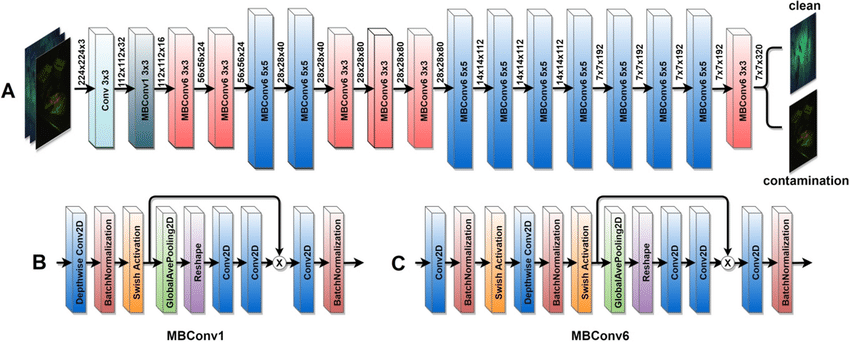

To achieve this, most of the steps will be based off of Luke Melas' well-documented pytorch implementation of the EfficientNet family's architecture. His repository can be visited [here](https://github.com/lukemelas/EfficientNet-PyTorch/blob/master/efficientnet_pytorch/model.py).

**Step 1:** Library definition

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
from PIL import Image
import os   
import time
import copy
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.7.1+cpu


**Step 2:** Defining MBConv Layer Functions

**Step 2.1:** Swish Activation Function

In [2]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

**Step 2.2:** Squeeze and Excitation Block
>Reduces the number of channels in the excitation phase to limit model complexity.



In [3]:
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduced_dim):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Squeeze: Global average pooling to [B, C, 1, 1]
            nn.Conv2d(in_channels, reduced_dim, kernel_size=1), # Excite: 1x1 conv to reduce channels
            Swish(),
            nn.Conv2d(reduced_dim, in_channels, kernel_size=1), # Excite: 1x1 conv to restore channels
            nn.Sigmoid(), # Get weights between 0 and 1
        )

    def forward(self, x):
        # x is the input feature map of shape [B, C, H, W]
        se_weights = self.se(x)
        # Multiply the input feature map by the learned channel-wise weights
        return x * se_weights

**Step 2.3:** Mobile Inverted Bottleneck Convolution (MBConv)

In [4]:
class MBConvBlock(nn.Module):
    """
    Args:
        in_channels (int): Number of input channels.
        out_channels (int): Number of output channels.
        kernel_size (int): Kernel size of the depthwise convolution.
        stride (int): Stride of the depthwise convolution.
        expand_ratio (int): Factor to expand the number of channels.
        se_ratio (float): Ratio for the squeeze-and-excitation block's reduced dimension.
        drop_connect_rate (float): Probability of dropping the main path (stochastic depth).
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride, expand_ratio, se_ratio=0.25):
        super().__init__()

        self.stride = stride
        # The residual connection only exists if input and output dimensions are the same
        self.use_res_connect = self.stride == 1 and in_channels == out_channels

        hidden_dim = in_channels * expand_ratio

        layers = []

        # 1. Expansion phase (if expand_ratio is not 1)
        if expand_ratio != 1:
            layers.append(nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False))
            layers.append(nn.BatchNorm2d(hidden_dim))
            layers.append(Swish())

        # 2. Depthwise convolution
        layers.append(
            nn.Conv2d(
                hidden_dim,
                hidden_dim,
                kernel_size,
                stride,
                padding=(kernel_size - 1) // 2,
                groups=hidden_dim,
                bias=False,
            )
        )
        layers.append(nn.BatchNorm2d(hidden_dim))
        layers.append(Swish())

        # 3. Squeeze and Excitation layer
        reduced_dim = max(1, int(in_channels * se_ratio))
        layers.append(SEBlock(hidden_dim, reduced_dim))

        # 4. Projection phase (pointwise convolution)
        layers.append(nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False))
        layers.append(nn.BatchNorm2d(out_channels))

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            # Add the original input (residual connection)
            return x + self.conv(x)
        else:
            return self.conv(x)

**Step 3:** Model Assembly

In [5]:
class EfficientNet(nn.Module):
    def __init__(self, version="b0", num_classes=1000):
        super().__init__()

        # Configuration for each version of EfficientNet
        # (expand_ratio, channels, repeats, stride, kernel_size)
        config = {
            "b0": [
                (1, 16, 1, 1, 3),
                (6, 24, 2, 2, 3),
                (6, 40, 2, 2, 5),
                (6, 80, 3, 2, 3),
                (6, 112, 3, 1, 5),
                (6, 192, 4, 2, 5),
                (6, 320, 1, 1, 3),
            ]
        }

        # B0 specific parameters
        in_channels = 32
        last_channels = 1280
        dropout_rate = 0.2

        # Stem (the first layer)
        self.stem = nn.Sequential(
            nn.Conv2d(3, in_channels, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            Swish(),
        )

        # Build stages from the MBConv blocks
        self.blocks = nn.ModuleList([])
        for expand_ratio, channels, repeats, stride, kernel_size in config[version]:
            out_channels = channels
            # The first block of each stage handles the stride and channel change
            self.blocks.append(
                MBConvBlock(in_channels, out_channels, kernel_size, stride, expand_ratio)
            )
            in_channels = out_channels
            # The rest of the blocks in the stage
            for _ in range(repeats - 1):
                self.blocks.append(
                    MBConvBlock(in_channels, out_channels, kernel_size, 1, expand_ratio)
                )

        # Head (the final layers)
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, last_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(last_channels),
            Swish(),
        )

        # Final classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(last_channels, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        for block in self.blocks:
            x = block(x)
        x = self.head(x)
        x = self.classifier(x)
        return x

# **Model Training Stage**

**Step 1:** Importing & Model Definition

In [6]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
from PIL import Image
import os
import time
import copy
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class SEBlock(nn.Module):
    def __init__(self, in_channels, reduced_dim):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, reduced_dim, kernel_size=1),
            Swish(),
            nn.Conv2d(reduced_dim, in_channels, kernel_size=1),
            nn.Sigmoid(),
        )
    def forward(self, x):
        se_weights = self.se(x)
        return x * se_weights

class MBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, expand_ratio, se_ratio=0.25):
        super().__init__()
        self.stride = stride
        self.use_res_connect = self.stride == 1 and in_channels == out_channels
        hidden_dim = in_channels * expand_ratio

        layers = []
        if expand_ratio != 1:
            layers.append(nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False))
            layers.append(nn.BatchNorm2d(hidden_dim))
            layers.append(Swish())

        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size, stride, padding=(kernel_size - 1) // 2, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            Swish()
        ])

        reduced_dim = max(1, int(in_channels * se_ratio))
        layers.append(SEBlock(hidden_dim, reduced_dim))

        layers.extend([
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels)
        ])

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

class EfficientNet(nn.Module):
    def __init__(self, version="b0", num_classes=1000):
        super().__init__()
        config = {
            "b0": [(1, 16, 1, 1, 3), (6, 24, 2, 2, 3), (6, 40, 2, 2, 5), (6, 80, 3, 2, 3),
                   (6, 112, 3, 1, 5), (6, 192, 4, 2, 5), (6, 320, 1, 1, 3)]
        }
        in_channels = 32
        last_channels = 1280
        dropout_rate = 0.2

        self.stem = nn.Sequential(
            nn.Conv2d(3, in_channels, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            Swish(),
        )

        self.blocks = nn.ModuleList([])
        for expand_ratio, channels, repeats, stride, kernel_size in config[version]:
            out_channels = channels
            self.blocks.append(MBConvBlock(in_channels, out_channels, kernel_size, stride, expand_ratio))
            in_channels = out_channels
            for _ in range(repeats - 1):
                self.blocks.append(MBConvBlock(in_channels, out_channels, kernel_size, 1, expand_ratio))

        self.head = nn.Sequential(
            nn.Conv2d(in_channels, last_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(last_channels),
            Swish(),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(last_channels, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        for block in self.blocks:
            x = block(x)
        x = self.head(x)
        x = self.classifier(x)
        return x

print("✅ Block 1: Model definition complete.")

✅ Block 1: Model definition complete.


**Step 2:** Dataset Loading

In [7]:
import pandas as pd
from PIL import Image
import os
from torch.utils.data import Dataset

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        """
        Args:
            annotations_file (string): Path to the csv file with annotations.
            img_dir (string): Directory with all the images.
        """
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform

        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.img_labels['label'].unique())}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        # Construct full image path
        img_name = self.img_labels.iloc[idx]['image_filename']
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        # Get label from the dataframe and map it to an integer index
        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]

        if self.transform:
          image = self.transform(image)

        return image, label_idx

print("✅ Block 2: Custom Dataset class defined.")

✅ Block 2: Custom Dataset class defined.


**Step 3:** Data Setup

In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader
import os

PROJECT_FOLDER_IN_DRIVE = "G:/My Drive/DRdataset/DataSplits/"

FOLD_NUMBER = 1
BASE_PATH = os.path.join(PROJECT_FOLDER_IN_DRIVE, f"fold_{FOLD_NUMBER}")

TRAIN_IMG_DIR = os.path.join(BASE_PATH, "augmented_train_images") # Path to training images
TEST_IMG_DIR = os.path.join(BASE_PATH, "test_images")   # Path to testing images

TRAIN_CSV = os.path.join(BASE_PATH, "augmented_train_labels.csv")
TEST_CSV = os.path.join(BASE_PATH, "test_labels.csv")

# --- Model & Training Parameters ---
BATCH_SIZE = 32
IMG_SIZE = 224

# --- Transforms ---
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    ]),
    'val': transforms.Compose([
        transforms.Resize(IMG_SIZE + 32),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
}

# --- Create Datasets and DataLoaders ---

# Create the training dataset by pairing the training CSV with the training image folder
train_dataset = CustomImageDataset(
    annotations_file=TRAIN_CSV,
    img_dir=TRAIN_IMG_DIR,
    transform=data_transforms['train']
)

# Create the validation dataset by pairing the testing CSV with the testing image folder
val_dataset = CustomImageDataset(
    annotations_file=TEST_CSV,
    img_dir=TEST_IMG_DIR,
    transform=data_transforms['val']
)


dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
}

dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
num_classes = len(train_dataset.class_to_idx)

print(f"--- Loading data from Fold {FOLD_NUMBER} ---")
print(f"Number of classes: {num_classes}")
print(f"Training images: {dataset_sizes['train']} from '{TRAIN_IMG_DIR}'")
print(f"Validation images: {dataset_sizes['val']} from '{TEST_IMG_DIR}'")
print("\n✅ Data pipeline for the selected fold is ready.")

--- Loading data from Fold 1 ---
Number of classes: 5
Training images: 25000 from 'G:/My Drive/DRdataset/DataSplits/fold_1\augmented_train_images'
Validation images: 733 from 'G:/My Drive/DRdataset/DataSplits/fold_1\test_images'

✅ Data pipeline for the selected fold is ready.


**Step 4:** Training Loop Function

In [9]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            progress_bar = tqdm(dataloaders[phase], desc=f"{phase.capitalize()} Epoch {epoch+1}")

            for inputs, labels in progress_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), 'best_efficientnet_b0.pth')
                print("✨ New best model saved!")
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model, history

print("✅ Block 4: Training function defined.")

✅ Block 4: Training function defined.


**Step 5:** Traning Execution

In [ ]:
import torch
from torch import nn
import time
import copy
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# --- Setup ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the model with the correct number of classes
model = EfficientNet(version="b0", num_classes=num_classes)
model = model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
# A learning rate scheduler helps in fine-tuning the learning rate
from torch.optim.lr_scheduler import StepLR
scheduler = StepLR(optimizer, step_size=3, gamma=0.9)

# --- Start Training ---
NUM_EPOCHS = 10 # ACTION: Change number of epochs as needed
trained_model, training_history = train_model(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS)

print("\n--- Training Finished ---")

# --- Plot Results ---
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    ax1.plot(history['train_acc'], label='Train Acc')
    ax1.plot(history['val_acc'], label='Val Acc')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax2.plot(history['train_loss'], label='Train Loss')
    ax2.plot(history['val_loss'], label='Val Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    plt.show()

plot_history(training_history)
print("✅ Block 5: Execution complete.")